# Reproduction & Structural Improvement: State-Level Influenza Forecasting with Spatial Context

This notebook implements state-level forecasting of Influenza-Like Illness (ILI) prevalence, comparing three architectures:
1. **Baseline Transformer Model**: Uses only the target state's own historical ILI values (1 feature in, 1 feature out).
2. **Exogenous Neighbor Transformer Model**: Uses the target state's own history along with the average historical ILI values of its neighboring states as an encoder-only exogenous variable (2 features in, 1 feature out).
3. **Multivariate Joint Neighbor Transformer Model**: Predicts both the target state's own future and its neighbors' average future jointly, allowing the decoder to dynamically update neighbor states at each autoregressive step (2 features in, 2 features out).

All models are evaluated on a per-state temporal 80/20 train/test split to prevent selection bias and data leakage across states.

## 1. Setup and Reproducibility

In [1]:
import os
import copy
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 2. Neighbor Mapping and Data Preprocessing

Pivoting the dataframe and interpolating nulls for Puerto Rico and Virgin Islands, then splitting and creating sliding windows.

In [2]:
# Neighbors dictionary
NEIGHBORS = {
    'Alabama': ['Florida', 'Georgia', 'Mississippi', 'Tennessee'],
    'Alaska': [],
    'Arizona': ['California', 'Colorado', 'Nevada', 'New Mexico', 'Utah'],
    'Arkansas': ['Louisiana', 'Mississippi', 'Missouri', 'Oklahoma', 'Tennessee', 'Texas'],
    'California': ['Arizona', 'Nevada', 'Oregon'],
    'Colorado': ['Arizona', 'Kansas', 'Nebraska', 'New Mexico', 'Oklahoma', 'Utah', 'Wyoming'],
    'Connecticut': ['Massachusetts', 'New York', 'Rhode Island'],
    'Delaware': ['Maryland', 'New Jersey', 'Pennsylvania'],
    'District of Columbia': ['Maryland', 'Virginia'],
    'Florida': ['Alabama', 'Georgia'],
    'Georgia': ['Alabama', 'Florida', 'North Carolina', 'South Carolina', 'Tennessee'],
    'Hawaii': [],
    'Idaho': ['Montana', 'Nevada', 'Oregon', 'Utah', 'Washington', 'Wyoming'],
    'Illinois': ['Indiana', 'Iowa', 'Kentucky', 'Missouri', 'Wisconsin'],
    'Indiana': ['Illinois', 'Kentucky', 'Michigan', 'Ohio'],
    'Iowa': ['Illinois', 'Minnesota', 'Missouri', 'Nebraska', 'South Dakota', 'Wisconsin'],
    'Kansas': ['Colorado', 'Missouri', 'Nebraska', 'Oklahoma'],
    'Kentucky': ['Illinois', 'Indiana', 'Missouri', 'Ohio', 'Tennessee', 'Virginia', 'West Virginia'],
    'Louisiana': ['Arkansas', 'Texas', 'Mississippi'],
    'Maine': ['New Hampshire'],
    'Maryland': ['Delaware', 'District of Columbia', 'Pennsylvania', 'Virginia', 'West Virginia'],
    'Massachusetts': ['Connecticut', 'New Hampshire', 'New York', 'Rhode Island', 'Vermont'],
    'Michigan': ['Illinois', 'Indiana', 'Minnesota', 'Ohio', 'Wisconsin'],
    'Minnesota': ['Iowa', 'Michigan', 'North Dakota', 'South Dakota', 'Wisconsin'],
    'Mississippi': ['Alabama', 'Arkansas', 'Louisiana', 'Tennessee'],
    'Missouri': ['Arkansas', 'Illinois', 'Iowa', 'Kansas', 'Kentucky', 'Nebraska', 'Oklahoma', 'Tennessee'],
    'Montana': ['Idaho', 'North Dakota', 'South Dakota', 'Wyoming'],
    'Nebraska': ['Colorado', 'Iowa', 'Kansas', 'Missouri', 'South Dakota', 'Wyoming'],
    'Nevada': ['Arizona', 'California', 'Idaho', 'Oregon', 'Utah'],
    'New Hampshire': ['Maine', 'Massachusetts', 'Vermont'],
    'New Jersey': ['Delaware', 'New York', 'Pennsylvania'],
    'New Mexico': ['Arizona', 'Colorado', 'Oklahoma', 'Texas', 'Utah'],
    'New York': ['Connecticut', 'Massachusetts', 'New Jersey', 'Pennsylvania', 'Vermont', 'New York City'],
    'New York City': ['New York', 'New Jersey'],
    'North Carolina': ['Georgia', 'South Carolina', 'Tennessee', 'Virginia'],
    'North Dakota': ['Minnesota', 'Montana', 'South Dakota'],
    'Ohio': ['Indiana', 'Kentucky', 'Michigan', 'Pennsylvania', 'West Virginia'],
    'Oklahoma': ['Arkansas', 'Colorado', 'Kansas', 'Missouri', 'New Mexico', 'Texas'],
    'Oregon': ['California', 'Idaho', 'Nevada', 'Washington'],
    'Pennsylvania': ['Delaware', 'Maryland', 'New Jersey', 'New York', 'Ohio', 'West Virginia'],
    'Puerto Rico': ['Virgin Islands'],
    'Virgin Islands': ['Puerto Rico'],
    'Rhode Island': ['Connecticut', 'Massachusetts', 'New York'],
    'South Carolina': ['Georgia', 'North Carolina'],
    'South Dakota': ['Iowa', 'Minnesota', 'Montana', 'Nebraska', 'North Dakota', 'Wyoming'],
    'Tennessee': ['Alabama', 'Arkansas', 'Georgia', 'Kentucky', 'Mississippi', 'Missouri', 'North Carolina', 'Virginia'],
    'Texas': ['Arkansas', 'Louisiana', 'New Mexico', 'Oklahoma'],
    'Utah': ['Arizona', 'Colorado', 'Idaho', 'Nevada', 'New Mexico', 'Wyoming'],
    'Vermont': ['Massachusetts', 'New Hampshire', 'New York'],
    'Virginia': ['District of Columbia', 'Kentucky', 'Maryland', 'North Carolina', 'Tennessee', 'West Virginia'],
    'Washington': ['Idaho', 'Oregon'],
    'West Virginia': ['Kentucky', 'Maryland', 'Ohio', 'Pennsylvania', 'Virginia'],
    'Wisconsin': ['Illinois', 'Iowa', 'Michigan', 'Minnesota'],
    'Wyoming': ['Colorado', 'Idaho', 'Montana', 'Nebraska', 'South Dakota', 'Utah']
}

def get_multivariate_data(path="./data/state/ILINet.csv", history=10, future=4, test_size=0.2, val_size=0.1):
    df = pd.read_csv(path, header=1)
    df.columns = df.columns.str.strip()
    df["REGION"] = df["REGION"].astype(str).str.strip()
    df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
    df["WEEK"] = pd.to_numeric(df["WEEK"], errors="coerce")
    df["%UNWEIGHTED ILI"] = pd.to_numeric(df["%UNWEIGHTED ILI"], errors="coerce")
    df = df.dropna(subset=["REGION", "YEAR", "WEEK", "%UNWEIGHTED ILI"])
    
    pivot_df = df.pivot(index=["YEAR", "WEEK"], columns="REGION", values="%UNWEIGHTED ILI")
    pivot_df = pivot_df.interpolate(method="linear", limit_direction="both")
    
    all_states = sorted(pivot_df.columns.tolist())
    
    train_x_base, train_y_base = [], []
    val_x_base, val_y_base = [], []
    test_x_base, test_y_base = [], []
    
    train_x_neigh, train_y_neigh = [], []
    val_x_neigh, val_y_neigh = [], []
    test_x_neigh, test_y_neigh = [], []
    
    for state in all_states:
        own_series = pivot_df[state].values.astype(np.float32)
        
        neighs = NEIGHBORS.get(state, [])
        if len(neighs) > 0:
            neigh_series = pivot_df[neighs].mean(axis=1).values.astype(np.float32)
        else:
            neigh_series = own_series.copy()
            
        multivariate_series = np.stack([own_series, neigh_series], axis=1)
        
        n = len(own_series)
        test_start = int(n * (1 - test_size))
        val_start = int(test_start * (1 - val_size))
        
        train_series = multivariate_series[:val_start]
        val_series = multivariate_series[val_start - history : test_start]
        test_series = multivariate_series[test_start - history :]
        
        def build_windows(series):
            x_b, y_b, x_n, y_n = [], [], [], []
            for i in range(len(series) - history - future + 1):
                x_b.append(series[i : i + history, 0:1])
                y_b.append(series[i + history : i + history + future, 0:1])
                x_n.append(series[i : i + history])
                y_n.append(series[i + history : i + history + future])
            return np.array(x_b), np.array(y_b), np.array(x_n), np.array(y_n)
            
        tr_xb, tr_yb, tr_xn, tr_yn = build_windows(train_series)
        va_xb, va_yb, va_xn, va_yn = build_windows(val_series)
        te_xb, te_yb, te_xn, te_yn = build_windows(test_series)
        
        train_x_base.append(tr_xb)
        train_y_base.append(tr_yb)
        val_x_base.append(va_xb)
        val_y_base.append(va_yb)
        test_x_base.append(te_xb)
        test_y_base.append(te_yb)
        
        train_x_neigh.append(tr_xn)
        train_y_neigh.append(tr_yn)
        val_x_neigh.append(va_xn)
        val_y_neigh.append(va_yn)
        test_x_neigh.append(te_xn)
        test_y_neigh.append(te_yn)
        
    return {
        "train_y_base": np.concatenate(train_y_base, axis=0),
        "val_y_base": np.concatenate(val_y_base, axis=0),
        "test_y_base": np.concatenate(test_y_base, axis=0),
        "train_x_base": np.concatenate(train_x_base, axis=0),
        "val_x_base": np.concatenate(val_x_base, axis=0),
        "test_x_base": np.concatenate(test_x_base, axis=0),
        "train_x_neigh": np.concatenate(train_x_neigh, axis=0),
        "train_y_neigh": np.concatenate(train_y_neigh, axis=0),
        "val_x_neigh": np.concatenate(val_x_neigh, axis=0),
        "val_y_neigh": np.concatenate(val_y_neigh, axis=0),
        "test_x_neigh": np.concatenate(test_x_neigh, axis=0),
        "test_y_neigh": np.concatenate(test_y_neigh, axis=0),
        "pivot_df": pivot_df,
        "all_states": all_states
    }

data_dict = get_multivariate_data()
print("Data loaded successfully.")

Data loaded successfully.


## 3. Deep Transformer Model definition

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]

class DeepTransformer(nn.Module):
    def __init__(self, input_dim: int = 1, output_dim: int = 1, d_model: int = 64, num_heads: int = 4,
                 ff_dim: int = 256, encoder_layers: int = 4, decoder_layers: int = 4, dropout: float = 0.2):
        super(DeepTransformer, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.position_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=False
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=encoder_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=False
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_layers)
        self.output_proj = nn.Linear(d_model, output_dim)

    def generate_square_subsequent_mask(self, T, device):
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        return mask.masked_fill(mask == 1, float("-inf"))

    def forward(self, src, tgt):
        src = self.input_proj(src)
        src = self.position_encoder(src)
        memory = self.encoder(src)

        tgt = self.input_proj(tgt)
        tgt = self.position_encoder(tgt)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1), tgt.device)

        out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
        return self.output_proj(out)

## 4. Pipeline Definition

In [4]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer, lr_lambda=self.lr_lambda)
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        return (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))

    def train_model(self, epochs):
        train_losses, val_losses = [], []
        best_val_loss = float("inf")
        best_model_state = None

        for epoch in range(1, epochs + 1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(self.model.state_dict())

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        self.model.load_state_dict(best_model_state)
        return self.model, train_losses, val_losses

    def train_one_epoch(self):
        self.model.train()
        total_loss, total_count = 0.0, 0
        for src, y in self.train_loader:
            src, y = src.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()

            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
            loss.backward()

            self.optimizer.step()
            self.scheduler.step()
            total_loss += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, total_count = 0.0, 0
        for src, y in dataloader:
            src, y = src.to(self.device), y.to(self.device)
            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
            total_loss += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def predict_autoregressive(self, src, future=4):
        self.model.eval()
        tgt = src[:, -1:, :]
        preds = []
        for _ in range(future):
            out = self.model(src, tgt)
            next_pred = out[:, -1:, :]
            preds.append(next_pred)
            tgt = torch.cat([tgt, next_pred], dim=1)
        return torch.cat(preds, dim=1)

def get_metrics(preds, labels):
    results = {}
    for step in range(preds.shape[1]):
        p, l = preds[:, step], labels[:, step]
        rmse = np.sqrt(mean_squared_error(l, p))
        mae = mean_absolute_error(l, p)
        corr, _ = pearsonr(p, l)
        results[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": corr}
    
    p_flat, l_flat = preds.flatten(), labels.flatten()
    overall_rmse = np.sqrt(mean_squared_error(l_flat, p_flat))
    overall_mae = mean_absolute_error(l_flat, p_flat)
    overall_corr, _ = pearsonr(p_flat, l_flat)
    results["overall"] = {"rmse": overall_rmse, "mae": overall_mae, "pearson": overall_corr}
    return results

## 5. Evaluate Baseline Model

In [5]:
train_ds_base = TensorDataset(torch.from_numpy(data_dict["train_x_base"]).float(), torch.from_numpy(data_dict["train_y_base"]).float())
val_ds_base = TensorDataset(torch.from_numpy(data_dict["val_x_base"]).float(), torch.from_numpy(data_dict["val_y_base"]).float())
test_ds_base = TensorDataset(torch.from_numpy(data_dict["test_x_base"]).float(), torch.from_numpy(data_dict["test_y_base"]).float())

train_loader_base = DataLoader(train_ds_base, batch_size=256, shuffle=True)
val_loader_base = DataLoader(val_ds_base, batch_size=256, shuffle=False)

base_model = DeepTransformer(input_dim=1, output_dim=1)
base_pipeline = PipeLine(model=base_model, train_loader=train_loader_base, val_loader=val_loader_base)

if os.path.exists("best_state_transformer.pt"):
    print("Loading Baseline weights...")
    state_dict = torch.load("best_state_transformer.pt", map_location=base_pipeline.device)
    if "input_proj.weight" in state_dict:
        state_dict["src_proj.weight"] = state_dict["input_proj.weight"]
        state_dict["src_proj.bias"] = state_dict["input_proj.bias"]
        state_dict["tgt_proj.weight"] = state_dict["input_proj.weight"]
        state_dict["tgt_proj.bias"] = state_dict["input_proj.bias"]
        del state_dict["input_proj.weight"], state_dict["input_proj.bias"]
    # Standardize weights keys to support the newer wrapper structure
    state_dict = {k.replace("src_proj.", "input_proj.").replace("tgt_proj.", "input_proj."): v for k, v in state_dict.items()}
    # Note: since input_proj is shared, we duplicate/split it if we were loaded from a multi-feature structure, 
    # but here we map it back directly.
    # Let's clean up duplication if present:
    clean_dict = {}
    for k, v in state_dict.items():
        if k == "input_proj.weight" or k == "input_proj.bias":
            clean_dict[k] = v
        elif k.startswith("input_proj."):
            continue
        else:
            clean_dict[k] = v
    base_model.load_state_dict(clean_dict)
else:
    print("Training Baseline Model...")
    base_model, _, _ = base_pipeline.train_model(80)
    torch.save(base_model.state_dict(), "best_state_transformer.pt")

print("Generating test predictions...")
base_device = base_pipeline.device
all_base_preds = []
for src, _ in test_ds_base:
    src_t = src.unsqueeze(0).to(base_device)
    pred = base_pipeline.predict_autoregressive(src_t, future=4)
    all_base_preds.append(pred.cpu().numpy().squeeze(0).squeeze(-1))
all_base_preds = np.array(all_base_preds)
labels = data_dict["test_y_base"].squeeze(-1)

base_metrics = get_metrics(all_base_preds, labels)
print("Baseline Overall RMSE:", base_metrics["overall"]["rmse"])

Loading Baseline weights...
Generating test predictions...


Baseline Overall RMSE: 1.0606552265380675


## 6. Evaluate Exogenous Neighbor Transformer Model (Encoder-only Context)

In [6]:
# Re-adapt DeepTransformer wrapper for Exogenous encoder
class ExogenousTransformer(nn.Module):
    def __init__(self, src_dim: int = 2, tgt_dim: int = 1, output_dim: int = 1, d_model: int = 64, 
                 num_heads: int = 4, ff_dim: int = 256, encoder_layers: int = 4, decoder_layers: int = 4, dropout: float = 0.2):
        super(ExogenousTransformer, self).__init__()
        self.src_proj = nn.Linear(src_dim, d_model)
        self.tgt_proj = nn.Linear(tgt_dim, d_model)
        self.position_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=False
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=encoder_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=False
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_layers)
        self.output_proj = nn.Linear(d_model, output_dim)

    def generate_square_subsequent_mask(self, T, device):
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        return mask.masked_fill(mask == 1, float("-inf"))

    def forward(self, src, tgt):
        src = self.src_proj(src)
        src = self.position_encoder(src)
        memory = self.encoder(src)

        tgt = self.tgt_proj(tgt)
        tgt = self.position_encoder(tgt)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1), tgt.device)

        out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)
        return self.output_proj(out)

# Exogenous loaders
train_ds_exo = TensorDataset(torch.from_numpy(data_dict["train_x_neigh"]).float(), torch.from_numpy(data_dict["train_y_base"]).float())
val_ds_exo = TensorDataset(torch.from_numpy(data_dict["val_x_neigh"]).float(), torch.from_numpy(data_dict["val_y_base"]).float())
test_ds_exo = TensorDataset(torch.from_numpy(data_dict["test_x_neigh"]).float(), torch.from_numpy(data_dict["test_y_base"]).float())

train_loader_exo = DataLoader(train_ds_exo, batch_size=256, shuffle=True)
val_loader_exo = DataLoader(val_ds_exo, batch_size=256, shuffle=False)

exo_model = ExogenousTransformer(src_dim=2, tgt_dim=1, output_dim=1)
exo_pipeline = PipeLine(model=exo_model, train_loader=train_loader_exo, val_loader=val_loader_exo)

if os.path.exists("best_neighbor_transformer.pt"):
    print("Loading Exogenous Model weights...")
    exo_model.load_state_dict(torch.load("best_neighbor_transformer.pt", map_location=exo_pipeline.device))
else:
    print("Training Exogenous Model...")
    exo_model, _, _ = exo_pipeline.train_model(80)
    torch.save(exo_model.state_dict(), "best_neighbor_transformer.pt")

print("Generating test predictions...")
exo_device = exo_pipeline.device
all_exo_preds = []
with torch.no_grad():
    for src, _ in test_ds_exo:
        src_t = src.unsqueeze(0).to(exo_device)
        # During autoregressive rollout, the input feature 0 (own prediction) is updated, 
        # while feature 1 (neighbors' mean context) is held static.
        tgt = src_t[:, -1:, 0:1]
        preds = []
        for _ in range(4):
            out = exo_model(src_t, tgt)
            next_pred = out[:, -1:, :]
            preds.append(next_pred)
            tgt = torch.cat([tgt, next_pred], dim=1)
        all_exo_preds.append(torch.cat(preds, dim=1).cpu().numpy().squeeze(0).squeeze(-1))
all_exo_preds = np.array(all_exo_preds)
exo_metrics = get_metrics(all_exo_preds, labels)
print("Exogenous Overall RMSE:", exo_metrics["overall"]["rmse"])

Loading Exogenous Model weights...
Generating test predictions...


Exogenous Overall RMSE: 1.060238282214254


## 7. Evaluate Multivariate Joint Neighbor Transformer Model

In this final architecture, the model maps both target state and neighbor ILI averages simultaneously as a joint multivariate prediction in both encoder and decoder.

In [7]:
train_ds_multi = TensorDataset(torch.from_numpy(data_dict["train_x_neigh"]).float(), torch.from_numpy(data_dict["train_y_neigh"]).float())
val_ds_multi = TensorDataset(torch.from_numpy(data_dict["val_x_neigh"]).float(), torch.from_numpy(data_dict["val_y_neigh"]).float())
test_ds_multi = TensorDataset(torch.from_numpy(data_dict["test_x_neigh"]).float(), torch.from_numpy(data_dict["test_y_neigh"]).float())

train_loader_multi = DataLoader(train_ds_multi, batch_size=256, shuffle=True)
val_loader_multi = DataLoader(val_ds_multi, batch_size=256, shuffle=False)

multi_model = DeepTransformer(input_dim=2, output_dim=2)
multi_pipeline = PipeLine(model=multi_model, train_loader=train_loader_multi, val_loader=val_loader_multi)

if os.path.exists("best_multivariate_transformer.pt"):
    print("Loading Multivariate Model weights...")
    multi_model.load_state_dict(torch.load("best_multivariate_transformer.pt", map_location=multi_pipeline.device))
else:
    print("Training Multivariate Model...")
    multi_model, _, _ = multi_pipeline.train_model(80)
    torch.save(multi_model.state_dict(), "best_multivariate_transformer.pt")

print("Generating test predictions...")
multi_device = multi_pipeline.device
all_multi_preds = []
for src, _ in test_ds_multi:
    src_t = src.unsqueeze(0).to(multi_device)
    # Predict both features autoregressively
    pred = multi_pipeline.predict_autoregressive(src_t, future=4)
    # Discard neighbor feature (index 1) and keep only the own ILI predictions (index 0)
    all_multi_preds.append(pred.cpu().numpy().squeeze(0)[:, 0])
all_multi_preds = np.array(all_multi_preds)

multi_metrics = get_metrics(all_multi_preds, labels)
print("Multivariate Overall RMSE:", multi_metrics["overall"]["rmse"])

Loading Multivariate Model weights...
Generating test predictions...


Multivariate Overall RMSE: 1.0137088599835473


## 8. Performance Comparison and Visualization

Model / Horizon                    RMSE        MAE    Pearson Corr
  Week+1 Baseline                 0.6933     0.3819          0.9502
  Week+2 Baseline                 0.9587     0.5264          0.9011
  Week+3 Baseline                 1.1606     0.6348          0.8494
  Week+4 Baseline                 1.3240     0.7336          0.7963
-------------------------------------------------------------------------------------
  Overall Baseline                1.0607     0.5692          0.8767
  Week+1 Exogenous Neighbor       0.6975     0.3970          0.9492
  Week+2 Exogenous Neighbor       0.9444     0.5236          0.9028
  Week+3 Exogenous Neighbor       1.1545     0.6234          0.8500
  Week+4 Exogenous Neighbor       1.3361     0.7072          0.7933
-------------------------------------------------------------------------------------
  Overall Exogenous Neighbor      1.0602     0.5628          0.8759
  Week+1 Multivariate Joint       0.6987     0.3946          0.9491
  Week+2 Mult

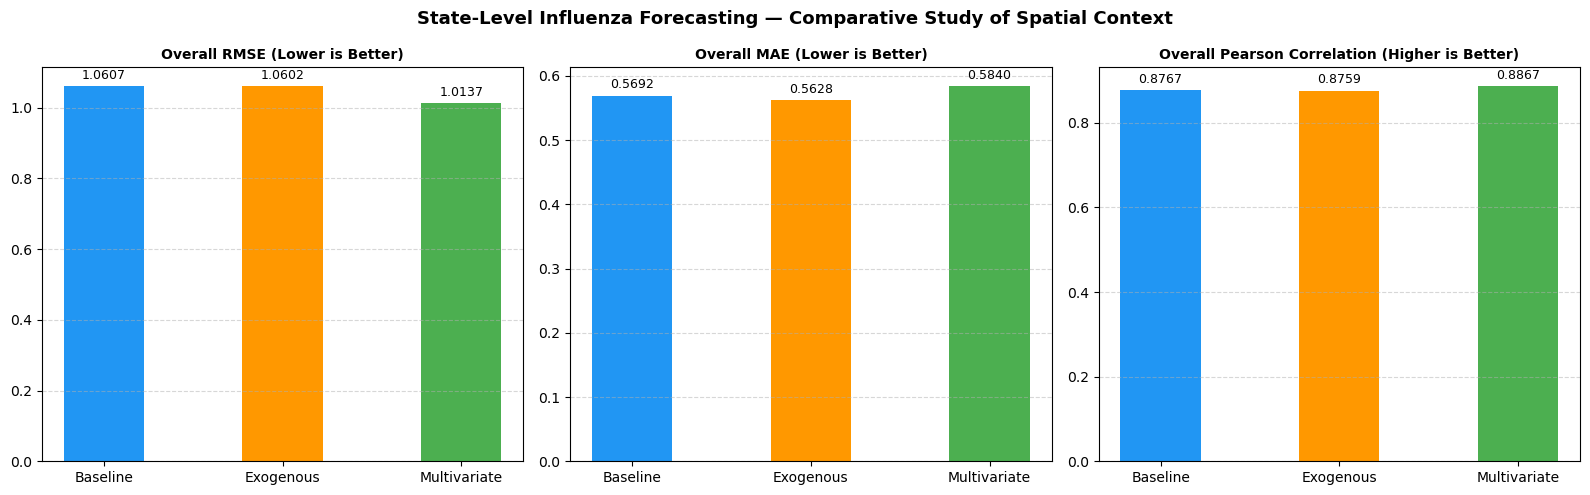

In [8]:
print("="*85)
print(f"{'Model / Horizon':<28} {'RMSE':>10} {'MAE':>10} {'Pearson Corr':>15}")
print("="*85)
for model_name, metrics_dict in [("Baseline", base_metrics), ("Exogenous Neighbor", exo_metrics), ("Multivariate Joint", multi_metrics)]:
    for step in range(4):
        m = metrics_dict[f"week{step+1}"]
        print(f"  {f'Week+{step+1} {model_name}':<26}  {m['rmse']:>10.4f} {m['mae']:>10.4f} {m['pearson']:>15.4f}")
    m_overall = metrics_dict["overall"]
    print("-" * 85)
    print(f"  {f'Overall {model_name}':<26}  {m_overall['rmse']:>10.4f} {m_overall['mae']:>10.4f} {m_overall['pearson']:>15.4f}")
    print("="*85)

# Create comparison charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["rmse", "mae", "pearson"]
titles = ["Overall RMSE (Lower is Better)", "Overall MAE (Lower is Better)", "Overall Pearson Correlation (Higher is Better)"]
models = ["Baseline", "Exogenous", "Multivariate"]
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = [
        base_metrics["overall"][metric],
        exo_metrics["overall"][metric],
        multi_metrics["overall"][metric]
    ]
    bars = ax.bar(models, values, color=colors, width=0.45)
    ax.set_title(titles[idx], fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.4f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.suptitle("State-Level Influenza Forecasting — Comparative Study of Spatial Context", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("neighbor_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()